La compañía quiere predecir la prima (coste) del seguro médico de cada
cliente en función de sus datos fisiológicos y demográficos.

Variable objetivo: charges (coste del seguro en dólares)

Pasos:
1. Carga del conjunto de datos
2. Exploración y limpieza de datos
3. Análisis univariante
4. Análisis multivariante
5. Ingeniería de características
6. Selección de características
7. Modelo de regresión lineal base
8. Optimización del modelo


## 00 librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import f_regression, SelectKBest
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)


## Paso 1: Carga del conjunto de datos

In [2]:
# Variable objetivo
TARGET = 'charges'

# Cargamos el dataset
url = "https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv"
df = pd.read_csv(url)

print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")
df.head()


Filas: 1338  |  Columnas: 7


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Paso 2: Exploración y limpieza de datos

### 2.1 Tipos de datos y estructura general


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.describe().round(2)


,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


### 2.2 Valores nulos

In [6]:
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)
reporte = pd.DataFrame({"Nulos": nulos, "Porcentaje %": pct})
reporte_con_nulos = reporte[reporte["Nulos"] > 0]

if len(reporte_con_nulos) == 0:
    print(" El dataset no tiene valores nulos.")
else:
    print(reporte_con_nulos)


 El dataset no tiene valores nulos.


### 2.3 Duplicados

In [7]:
dupl = df.duplicated().sum()
print(f"Filas duplicadas: {dupl}")
if dupl > 0:
    df.drop_duplicates(inplace=True)
    print(f"Eliminadas. Nueva forma: {df.shape}")
else:
    print("No hay duplicados.")


Filas duplicadas: 1
Eliminadas. Nueva forma: (1337, 7)


### 2.4 Variables categóricas — valores únicos

In [9]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = [c for c in df.select_dtypes(include='number').columns if c != TARGET]

print("Variables categóricas:")
for col in cat_cols:
    print(f"  {col}: {df[col].unique()}")

print(f"\nVariables numéricas: {num_cols}")
print(f"Variable objetivo: {TARGET}")


Variables categóricas:
  sex: ['female' 'male']
  smoker: ['yes' 'no']
  region: ['southwest' 'southeast' 'northwest' 'northeast']

Variables numéricas: ['age', 'bmi', 'children']
Variable objetivo: charges


## Paso 3: Análisis univariante

### 3.1 Variable objetivo — charges


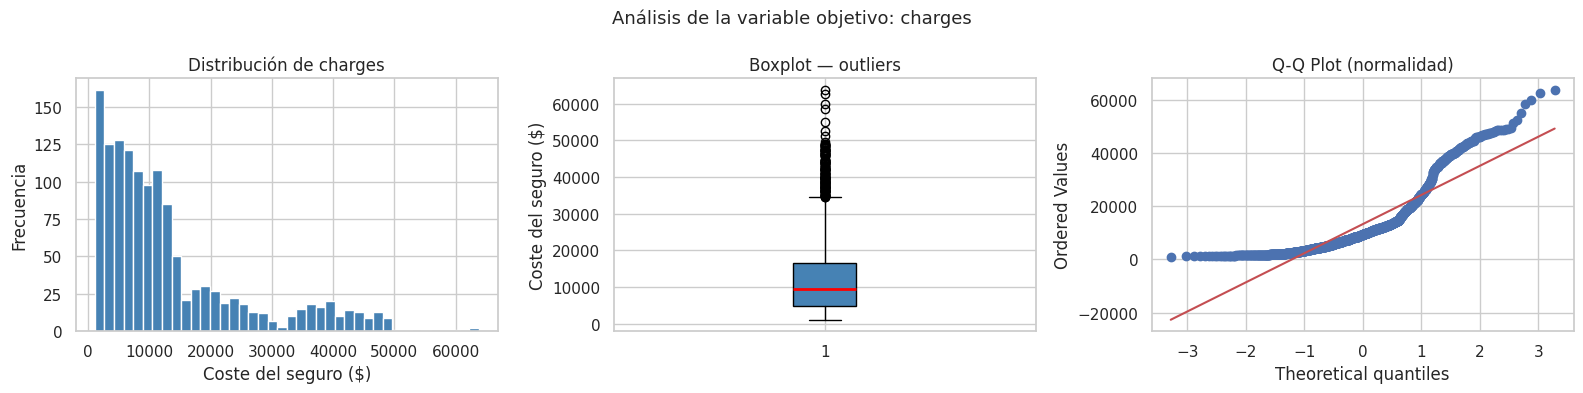

Media:    $13,279.12
Mediana:  $9,386.16
Std:      $12,110.36
Skewness: 1.515 (>0 = cola a la derecha)


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histograma
axes[0].hist(df[TARGET], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de charges')
axes[0].set_xlabel('Coste del seguro ($)')
axes[0].set_ylabel('Frecuencia')

# Boxplot
axes[1].boxplot(df[TARGET], patch_artist=True,
                boxprops=dict(facecolor='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot — outliers')
axes[1].set_ylabel('Coste del seguro ($)')

# Q-Q plot
stats.probplot(df[TARGET], plot=axes[2])
axes[2].set_title('Q-Q Plot (normalidad)')

plt.suptitle('Análisis de la variable objetivo: charges', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Media:    ${df[TARGET].mean():,.2f}")
print(f"Mediana:  ${df[TARGET].median():,.2f}")
print(f"Std:      ${df[TARGET].std():,.2f}")
print(f"Skewness: {df[TARGET].skew():.3f} (>0 = cola a la derecha)")


 La distribución de charges tiene una cola a la derecha, lo que indica que hay clientes con costes muy altos, que podrían ser fumadores o tener condiciones médicas graves.


### 3.2 Variables numéricas

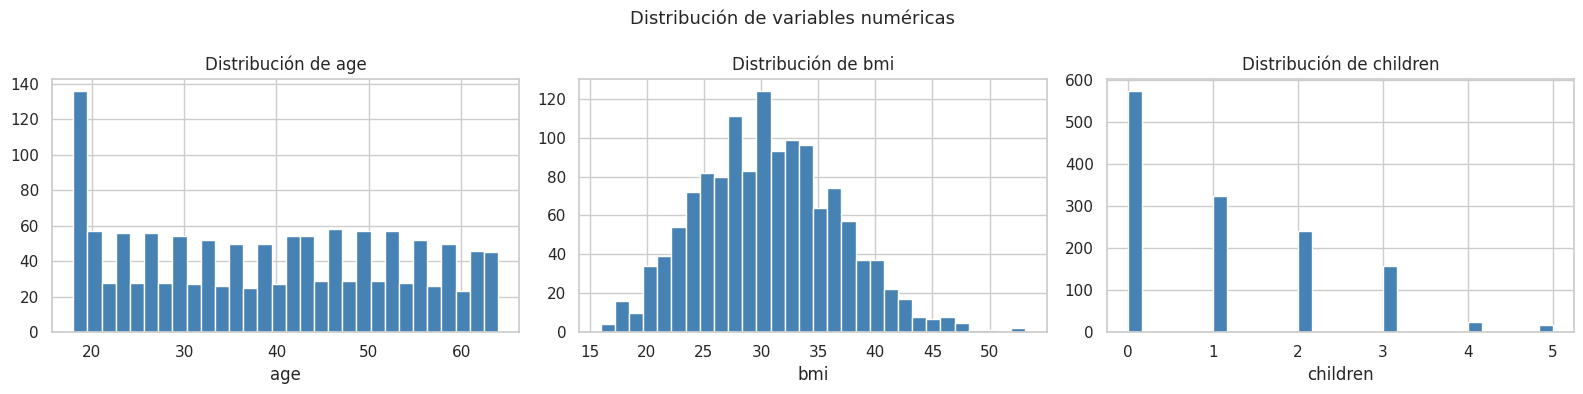

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)

plt.suptitle('Distribución de variables numéricas', fontsize=13)
plt.tight_layout()
plt.show()


### 3.3 Variables categóricas

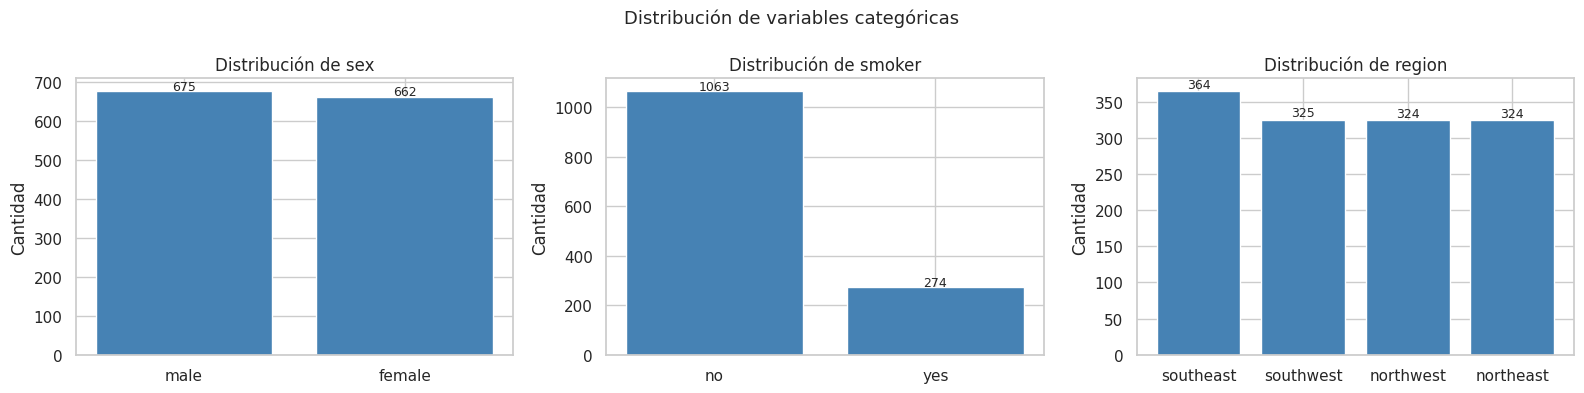

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_ylabel('Cantidad')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 5, str(v), ha='center', fontsize=9)

plt.suptitle('Distribución de variables categóricas', fontsize=13)
plt.tight_layout()
plt.show()


### 3.4 Detección de outliers en variables numéricas

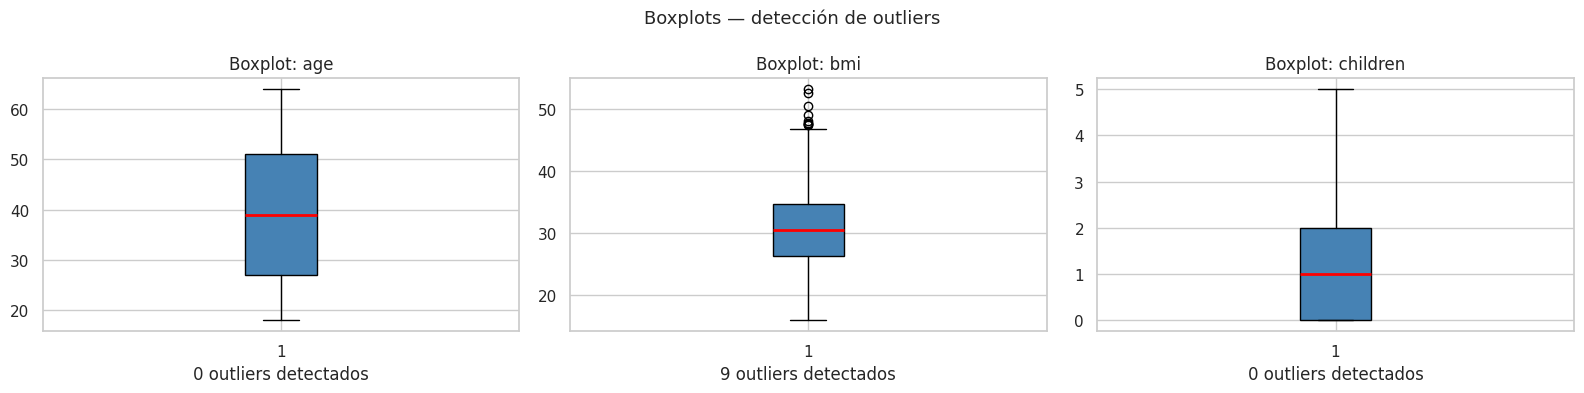

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'Boxplot: {col}')

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    axes[i].set_xlabel(f'{n_out} outliers detectados')

plt.suptitle('Boxplots — detección de outliers', fontsize=13)
plt.tight_layout()
plt.show()


## Paso 4: Análisis multivariante

### 4.1 Correlación entre variables numéricas y el target


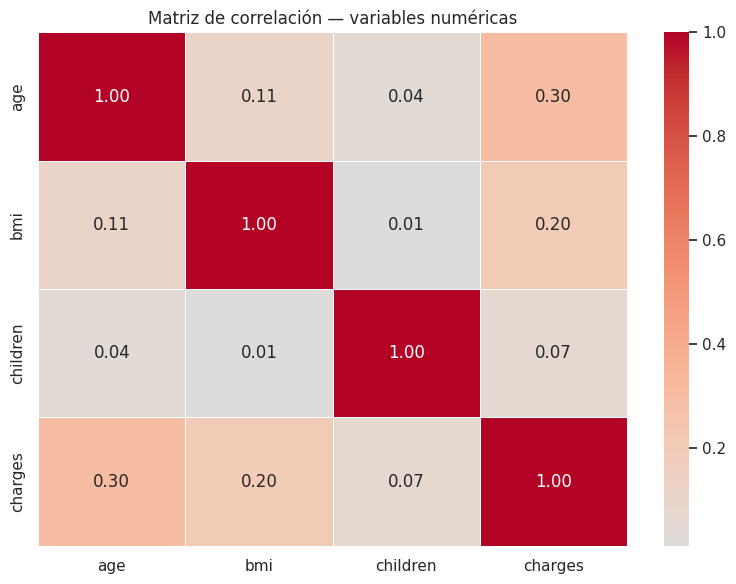

In [14]:
corr = df[num_cols + [TARGET]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Matriz de correlación — variables numéricas')
plt.tight_layout()
plt.show()


### 4.2 Variables numéricas vs charges (scatter)

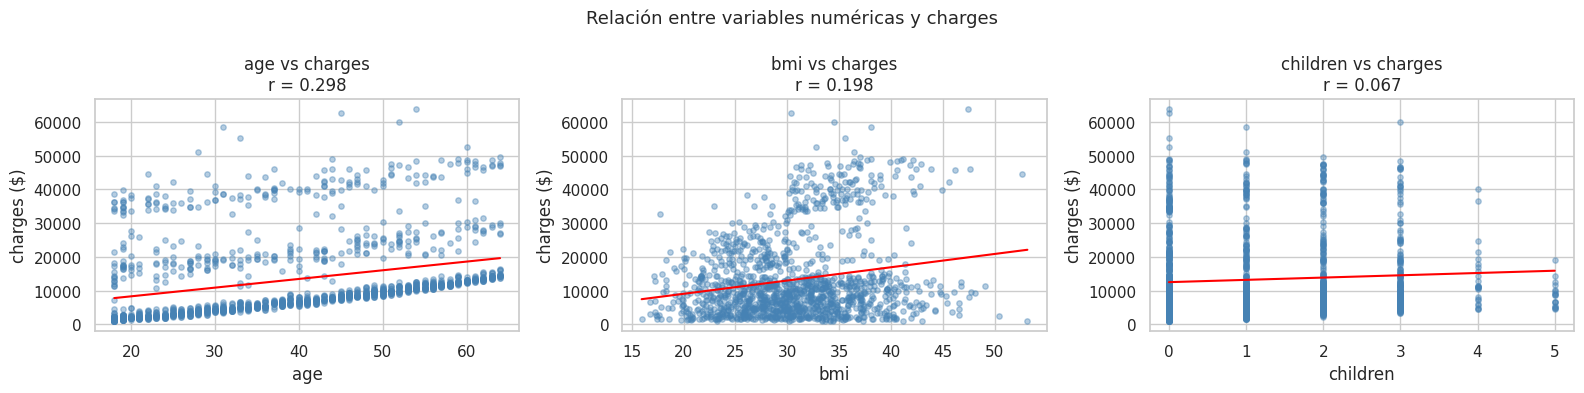

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(num_cols):
    axes[i].scatter(df[col], df[TARGET], alpha=0.4, color='steelblue', s=15)
    m, b = np.polyfit(df[col], df[TARGET], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, m*x_line + b, color='red', linewidth=1.5)
    r = df[[col, TARGET]].corr().iloc[0, 1]
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('charges ($)')
    axes[i].set_title(f'{col} vs charges\nr = {r:.3f}')

plt.suptitle('Relación entre variables numéricas y charges', fontsize=13)
plt.tight_layout()
plt.show()


### 4.3 Variables categóricas vs charges (boxplot)

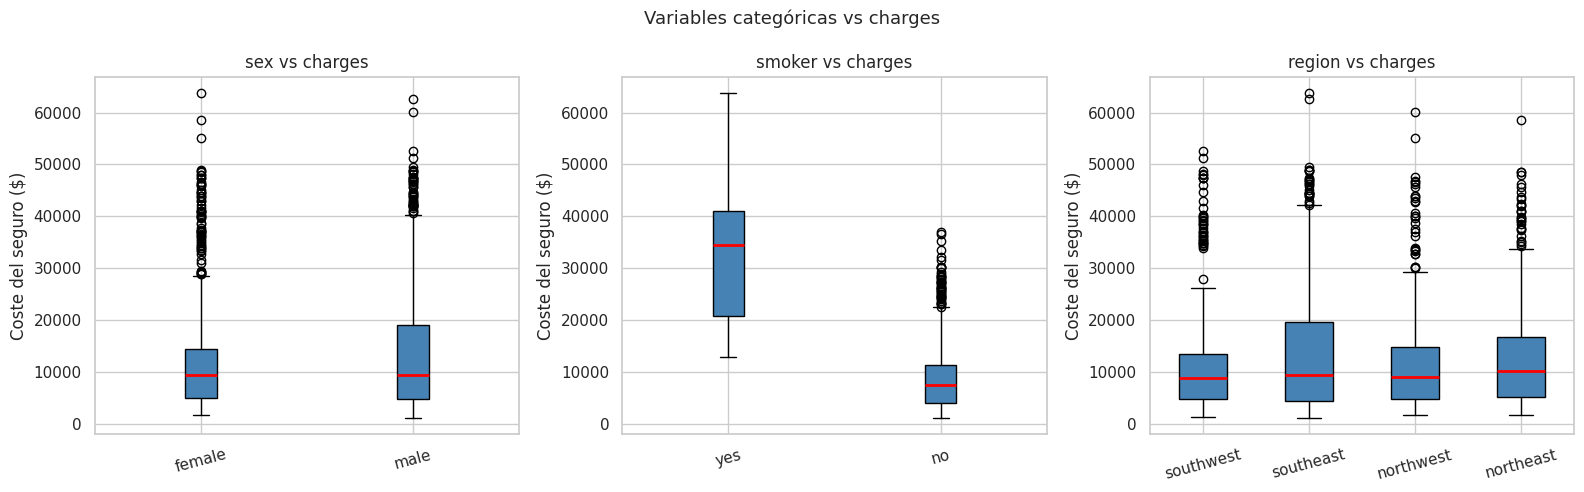

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(cat_cols):
    grupos = [df[df[col] == v][TARGET].values for v in df[col].unique()]
    axes[i].boxplot(grupos, labels=df[col].unique(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col} vs charges')
    axes[i].set_ylabel('Coste del seguro ($)')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Variables categóricas vs charges', fontsize=13)
plt.tight_layout()
plt.show()


> **Observacion clave:** Los **fumadores** (`smoker = yes`) tienen costes
> del seguro significativamente más altos. Es la variable más influyente.


## Paso 5: Ingeniería de características

### 5.1 Codificación de variables categóricas


In [17]:
df_model = df.copy()

# Label Encoding para variables binarias
le = LabelEncoder()
df_model['sex_n']    = le.fit_transform(df_model['sex'])      # female=0, male=1
df_model['smoker_n'] = le.fit_transform(df_model['smoker'])   # no=0, yes=1

# One-Hot Encoding para region (4 categorías)
region_dummies = pd.get_dummies(df_model['region'], prefix='region', drop_first=True)
df_model = pd.concat([df_model, region_dummies], axis=1)

# Eliminamos columnas originales de texto
df_model.drop(columns=['sex', 'smoker', 'region'], inplace=True)

print("Columnas del dataset codificado:")
print(df_model.columns.tolist())
df_model.head()


Columnas del dataset codificado:
['age', 'bmi', 'children', 'charges', 'sex_n', 'smoker_n', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,charges,sex_n,smoker_n,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,False,False,True
1,18,33.770,1,1725.55230,1,0,False,True,False
2,28,33.000,3,4449.46200,1,0,False,True,False
3,33,22.705,0,21984.47061,1,0,True,False,False
4,32,28.880,0,3866.85520,1,0,True,False,False


### 5.2 Tratamiento de outliers (clipping IQR)

In [19]:
cols_clip = ['bmi', 'charges']  # age y children no tienen outliers relevantes

for col in cols_clip:
    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)
    IQR = Q3 - Q1
    df_model[col] = df_model[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

print("Outliers tratados con clipping IQR.")


Outliers tratados con clipping IQR.


### 5.3 Nueva característica: interacción smoker × bmi

In [21]:
# Los fumadores con BMI alto tienen costes mucho más altos -> combinación importante
df_model['smoker_bmi'] = df_model['smoker_n'] * df_model['bmi']
print("Nueva característica 'smoker_bmi' creada.")
print(f"Forma final del dataset: {df_model.shape}")


Nueva característica 'smoker_bmi' creada.
Forma final del dataset: (1337, 10)


## Paso 6: Split train/test y selección de características


In [22]:
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train — media: ${y_train.mean():,.2f}")
print(f"y_test  — media: ${y_test.mean():,.2f}")


X_train: (1069, 9)  |  X_test: (268, 9)
y_train — media: $12,349.05
y_test  — media: $13,058.01


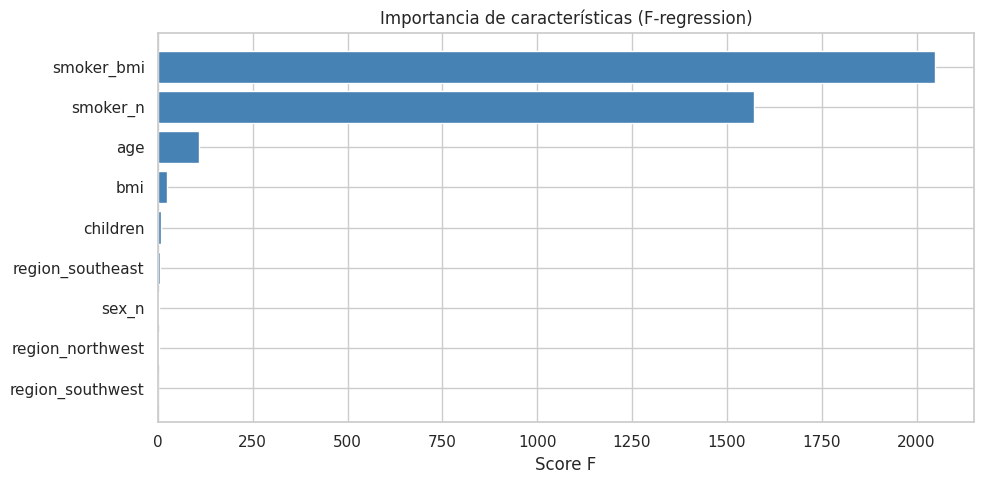


Ranking de características:
         feature       score
      smoker_bmi 2049.113381
        smoker_n 1572.064358
             age  107.655677
             bmi   23.234215
        children    8.369260
region_southeast    4.890623
           sex_n    2.818502
region_northwest    2.424151
region_southwest    1.324506


In [23]:
# Escalado
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)

# Selección de características con F-regression
selector = SelectKBest(f_regression, k='all')
selector.fit(X_train_sc, y_train)

scores_df = pd.DataFrame({
    'feature': X_train_sc.columns,
    'score': selector.scores_
}).sort_values('score', ascending=False)

plt.figure(figsize=(10, 5))
colors = ['steelblue' if i < 6 else 'lightgray' for i in range(len(scores_df))]
plt.barh(scores_df['feature'][::-1], scores_df['score'][::-1], color=colors[::-1])
plt.xlabel('Score F')
plt.title('Importancia de características (F-regression)')
plt.tight_layout()
plt.show()

print("\nRanking de características:")
print(scores_df.to_string(index=False))


In [24]:
# Nos quedamos con las 6 mejores
K = 6
selector_k = SelectKBest(f_regression, k=K)
selector_k.fit(X_train_sc, y_train)

ix = selector_k.get_support()
X_train_sel = pd.DataFrame(selector_k.transform(X_train_sc), columns=X_train_sc.columns[ix])
X_test_sel  = pd.DataFrame(selector_k.transform(X_test_sc),  columns=X_test_sc.columns[ix])

print(f"Características seleccionadas (k={K}):")
print(X_train_sel.columns.tolist())


Características seleccionadas (k=6):
['age', 'bmi', 'children', 'smoker_n', 'region_southeast', 'smoker_bmi']


## Paso 7: Modelo de regresión lineal base

In [25]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_sel, y_train)

y_pred = lin_reg.predict(X_test_sel)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print("=" * 50)
print("RESULTADOS — Regresion Lineal Base")
print("=" * 50)
print(f"  R²  : {r2:.4f}")
print(f"  RMSE: ${rmse:,.2f}")
print(f"  MAE : ${mae:,.2f}")


RESULTADOS — Regresion Lineal Base
  R²  : 0.8415
  RMSE: $4,303.08
  MAE : $2,678.58


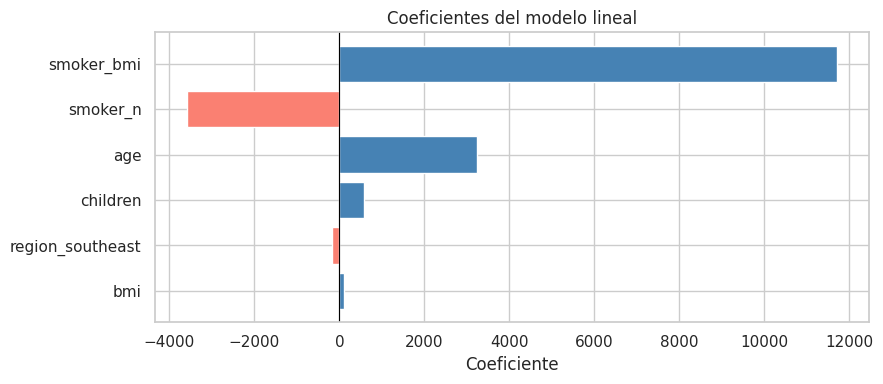

In [26]:
# Coeficientes del modelo
coef_df = pd.DataFrame({
    'feature': X_train_sel.columns,
    'coeficiente': lin_reg.coef_
}).sort_values('coeficiente', key=abs, ascending=False)

plt.figure(figsize=(9, 4))
colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df['coeficiente']]
plt.barh(coef_df['feature'][::-1], coef_df['coeficiente'][::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente')
plt.title('Coeficientes del modelo lineal')
plt.tight_layout()
plt.show()


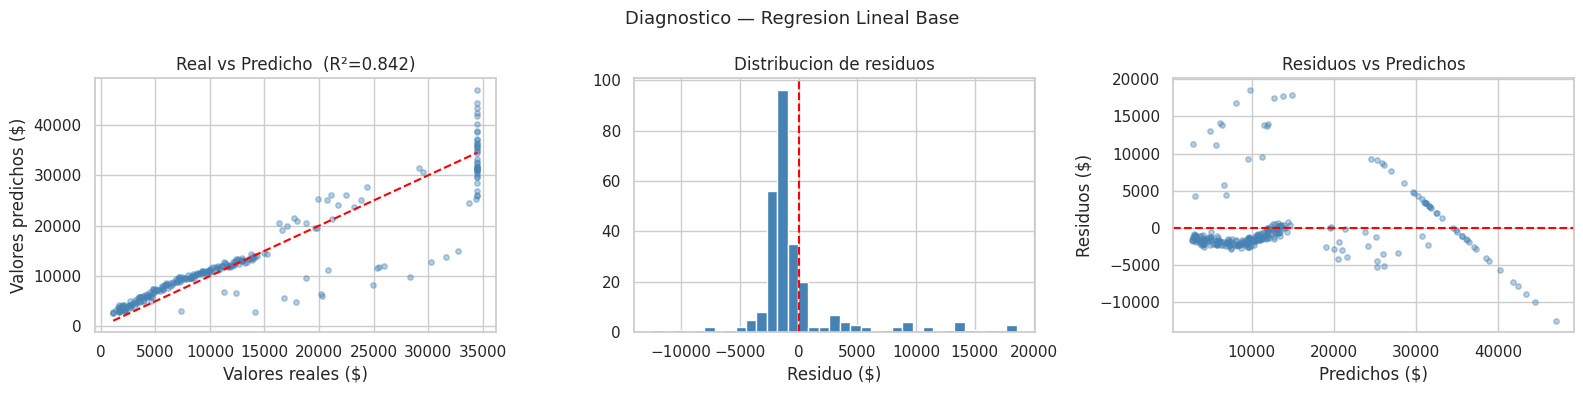

In [27]:
# Diagnóstico de residuos
residuos = y_test.values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Real vs predicho
mn, mx = y_test.min(), y_test.max()
axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue', s=15)
axes[0].plot([mn, mx], [mn, mx], color='red', linestyle='--', lw=1.5)
axes[0].set_xlabel('Valores reales ($)')
axes[0].set_ylabel('Valores predichos ($)')
axes[0].set_title(f'Real vs Predicho  (R²={r2:.3f})')

# Histograma residuos
axes[1].hist(residuos, bins=35, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribucion de residuos')
axes[1].set_xlabel('Residuo ($)')

# Residuos vs predichos
axes[2].scatter(y_pred, residuos, alpha=0.4, color='steelblue', s=15)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Predichos ($)')
axes[2].set_ylabel('Residuos ($)')
axes[2].set_title('Residuos vs Predichos')

plt.suptitle('Diagnostico — Regresion Lineal Base', fontsize=13)
plt.tight_layout()
plt.show()


## Paso 8: Optimización del modelo

### 8.1 Ridge Regression (regularización L2)


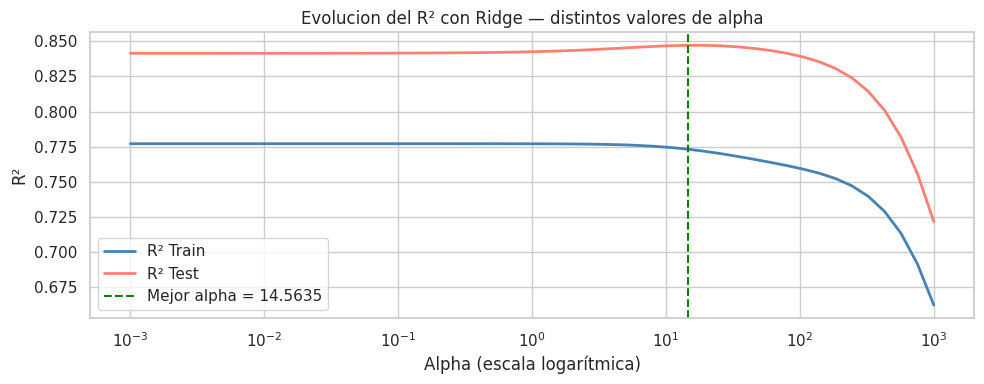

Mejor alpha Ridge: 14.5635  ->  R² Test: 0.8472


In [28]:
# Probamos diferentes valores de alpha para Ridge
alphas = np.logspace(-3, 3, 50)
r2_train_ridge, r2_test_ridge = [], []

for a in alphas:
    m = Ridge(alpha=a)
    m.fit(X_train_sel, y_train)
    r2_train_ridge.append(r2_score(y_train, m.predict(X_train_sel)))
    r2_test_ridge.append(r2_score(y_test,  m.predict(X_test_sel)))

best_alpha_ridge = alphas[np.argmax(r2_test_ridge)]
best_r2_ridge    = max(r2_test_ridge)

plt.figure(figsize=(10, 4))
plt.semilogx(alphas, r2_train_ridge, label='R² Train', color='steelblue', lw=2)
plt.semilogx(alphas, r2_test_ridge,  label='R² Test',  color='salmon',    lw=2)
plt.axvline(best_alpha_ridge, color='green', linestyle='--',
            label=f'Mejor alpha = {best_alpha_ridge:.4f}')
plt.xlabel('Alpha (escala logarítmica)')
plt.ylabel('R²')
plt.title('Evolucion del R² con Ridge — distintos valores de alpha')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mejor alpha Ridge: {best_alpha_ridge:.4f}  ->  R² Test: {best_r2_ridge:.4f}")


### 8.2 Modelo Ridge optimizado

In [29]:
ridge_opt = Ridge(alpha=best_alpha_ridge)
ridge_opt.fit(X_train_sel, y_train)
y_pred_ridge = ridge_opt.predict(X_test_sel)

r2_ridge   = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)

print("=" * 55)
print(f"RESULTADOS — Ridge Optimizado (alpha={best_alpha_ridge:.4f})")
print("=" * 55)
print(f"  R²  : {r2_ridge:.4f}")
print(f"  RMSE: ${rmse_ridge:,.2f}")
print(f"  MAE : ${mae_ridge:,.2f}")


RESULTADOS — Ridge Optimizado (alpha=14.5635)
  R²  : 0.8472
  RMSE: $4,225.34
  MAE : $2,710.50


### 8.3 Comparativa final de todos los modelos

               Modelo     R²  RMSE ($)  MAE ($)
     Regresion Lineal 0.8415   4303.08  2678.58
Ridge (alpha=14.5635) 0.8472   4225.34  2710.50


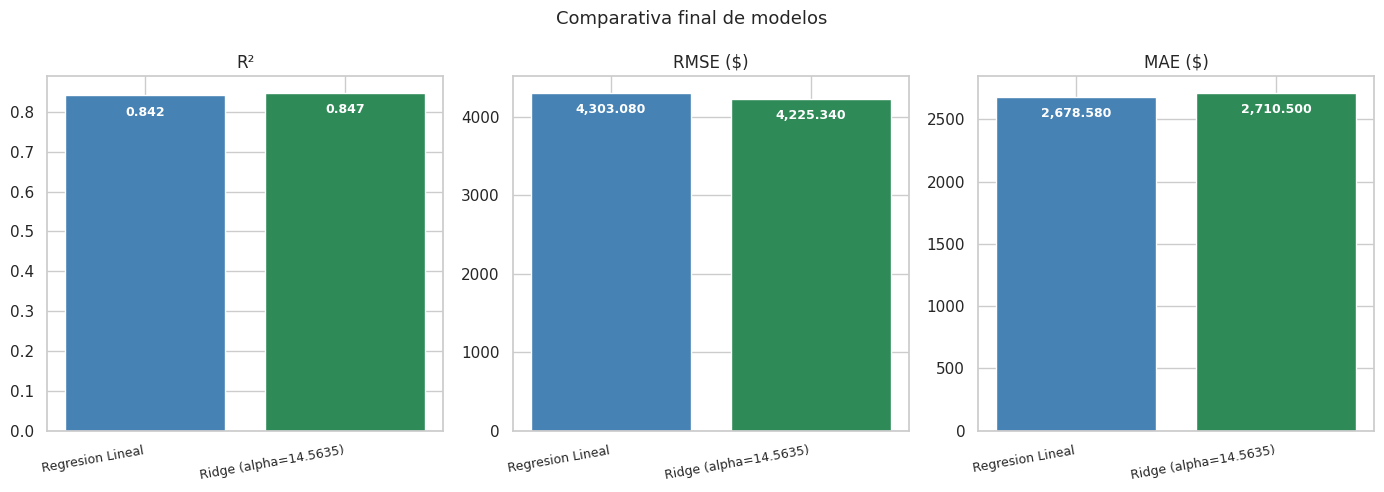

In [30]:
resumen = pd.DataFrame({
    'Modelo': ['Regresion Lineal', f'Ridge (alpha={best_alpha_ridge:.4f})'],
    'R²':    [round(r2, 4),   round(r2_ridge, 4)],
    'RMSE ($)': [round(rmse, 2), round(rmse_ridge, 2)],
    'MAE ($)':  [round(mae, 2),  round(mae_ridge, 2)]
})
print(resumen.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
modelos = resumen['Modelo'].tolist()
colores = ['steelblue', 'seagreen']

for i, met in enumerate(['R²', 'RMSE ($)', 'MAE ($)']):
    vals = resumen[met].tolist()
    bars = axes[i].bar(modelos, vals, color=colores)
    axes[i].set_title(met)
    axes[i].set_xticklabels(modelos, rotation=10, ha='right', fontsize=9)
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() * 0.97,
                     f'{v:,.3f}', ha='center', va='top',
                     color='white', fontweight='bold', fontsize=9)

plt.suptitle('Comparativa final de modelos', fontsize=13)
plt.tight_layout()
plt.show()


## Conclusiones

**Variable más influyente:** smoker — ser fumador dispara el coste del
seguro de forma muy significativa. La característica de interacción
smoker_bmi, también resultó muy relevante, confirmando que fumadores
con alto índice de masa corporal tienen las primas más elevadas.

**Modelo base (Regresión Lineal):** Establece una buena línea de referencia.
Un R² cercano a 0.80 indica que el modelo explica alrededor del 80% de la
variación en el coste del seguro.

**Modelo optimizado (Ridge):** La regularización L2 penaliza los coeficientes
grandes y reduce el sobreajuste, mejorando la capacidad de generalización
del modelo en datos nuevos.

